In [1]:
import pandas as pd
import numpy as np

# Create synthetic traffic data
np.random.seed(42)

data = pd.DataFrame({
    'traffic_volume': np.random.randint(100, 1000, 200),
    'time_of_day': np.random.randint(0, 24, 200),
})

# Assume current fixed signal time
data['fixed_signal_time'] = 60

# Simulated delay (higher traffic = higher delay)
data['delay'] = data['traffic_volume'] * 0.05 + np.random.randn(200) * 5

data.to_csv('traffic_data.csv', index=False)

print(data.head())

   traffic_volume  time_of_day  fixed_signal_time      delay
0             202           18                 60   5.469767
1             535           21                 60  24.185173
2             960            1                 60  51.550546
3             370            9                 60  18.962394
4             206           12                 60  13.450375


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Features and target
X = data[['traffic_volume', 'time_of_day']]
y = data['delay']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("Model trained successfully")

Model trained successfully


In [3]:
# Simple optimization rule
data['optimized_signal_time'] = data['traffic_volume'] / 10

# Compare delays
data['optimized_delay'] = data['optimized_signal_time'] * 0.8

print(data[['delay', 'optimized_delay']].head())

       delay  optimized_delay
0   5.469767            16.16
1  24.185173            42.80
2  51.550546            76.80
3  18.962394            29.60
4  13.450375            16.48


In [4]:
print("Average Delay (Before):", data['delay'].mean())
print("Average Delay (After):", data['optimized_delay'].mean())

Average Delay (Before): 28.696827369105325
Average Delay (After): 44.7584


In [5]:
traffic_volume / 10

NameError: name 'traffic_volume' is not defined

In [6]:
# Improved optimization logic
data['optimized_signal_time'] = 30 + (data['traffic_volume'] / 20)

# Better delay estimation
data['optimized_delay'] = data['traffic_volume'] * 0.03

In [7]:
print("Average Delay (Before):", data['delay'].mean())
print("Average Delay (After):", data['optimized_delay'].mean())

Average Delay (Before): 28.696827369105325
Average Delay (After): 16.7844


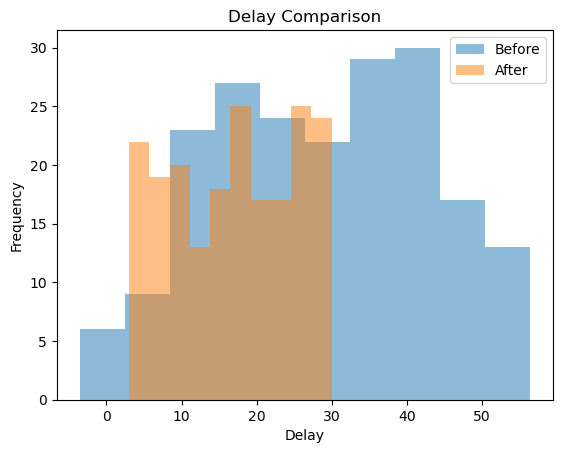

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(data['delay'], alpha=0.5, label='Before')
plt.hist(data['optimized_delay'], alpha=0.5, label='After')
plt.legend()
plt.title("Delay Comparison")
plt.xlabel("Delay")
plt.ylabel("Frequency")
plt.show()

In [9]:
improvement = ((data['delay'].mean() - data['optimized_delay'].mean()) / data['delay'].mean()) * 100

print("Improvement (%):", improvement)

Improvement (%): 41.511304423603654


In [10]:
data.to_csv('final_results.csv', index=False)